# Project 4b — Module 5: Statistical Inference
## Lesson 3: Probability Distributions

| | |
|---|---|
| **Author** | Jose Marcel Lopez Pino |
| **Framework** | CRISP-DM + LEAN |
| **Phase** | 3 — Data Preparation |
| **Module** | 5 — Statistical Inference (Alkemy Bootcamp) |
| **Dataset** | PequeShop — customers_final.csv + transactions_final.csv |
| **Date** | 2026-03 |

---

> **Executive Summary:**  
> This notebook identifies the probability distribution of each key variable
> (avg_ticket, total_transactions, churn) using normality tests, Q-Q plots,
> and distribution fitting. The output directly justifies the choice of
> statistical tests in notebook 06 — ensuring test assumptions are met before
> hypothesis testing begins.


## Table of Contents

1. [CRISP-DM Phase 3 — Data Preparation](#1-crisp-dm-phase-3--data-preparation)
2. [Load Data](#2-load-data)
3. [Normal Distribution — avg_ticket](#3-normal-distribution--avg_ticket)
4. [Poisson Distribution — total_transactions](#4-poisson-distribution--total_transactions)
5. [Binomial Distribution — Churn](#5-binomial-distribution--churn)
6. [Distribution Summary — Test Justification](#6-distribution-summary--test-justification)
7. [LEAN Filter — Waste Elimination Review](#7-lean-filter--waste-elimination-review)
8. [Decisions Log — Lesson 3](#8-decisions-log--lesson-3)
9. [Next Steps — Lesson 4 Preview](#9-next-steps--lesson-4-preview)


---
## 1. CRISP-DM Phase 3 — Data Preparation

### 1.1 Objective

In this phase we do not clean or transform data — the datasets are already
clean from project-2. Instead, we use this phase to **prepare the analytical
conditions** for modeling: verifying that each variable satisfies the
distributional assumptions required by the planned hypothesis tests.

### 1.2 Distribution → Test Mapping

| Variable | Expected Distribution | Justifies Test | Hypothesis |
|----------|--------------------|----------------|------------|
| `avg_ticket` | Normal (or CLT applies) | One-sample t-test, Welch t-test, ANOVA | H1, H2, H4 |
| `total_transactions` | Poisson | Descriptive context | — |
| churn (Dormant flag) | Binomial | Proportion z-test | H3 |

### 1.3 Lean Filter for This Phase

> *Only fit distributions that justify a planned test in notebook 06.
> Do not fit distributions for variables not used in any hypothesis.*


In [1]:
# ===== Environment Setup =====
import warnings
warnings.formatwarning = lambda msg, *args, **kwargs: f'Warning: {msg}\n'
warnings.simplefilter('always')
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns

# ===== Plot Style =====
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_d')

# ===== Reproducibility =====
np.random.seed(42)

# ===== Paths =====
DATA_PROCESSED  = Path('../data/processed')
REPORTS_FIGURES = Path('../reports/figures')
REPORTS_FIGURES.mkdir(parents=True, exist_ok=True)

print('Environment ready.')
print(f'Figures path: {REPORTS_FIGURES}')

Environment ready.
Figures path: ..\reports\figures


---
## 2. Load Data


In [2]:
# ===== Load Datasets =====
df_customers    = pd.read_csv(DATA_PROCESSED / 'customers_final.csv')
df_transactions = pd.read_csv(DATA_PROCESSED / 'transactions_final.csv')

print(f'customers_final   : {df_customers.shape}')
print(f'transactions_final: {df_transactions.shape}')
print()

# Key variables for this notebook
avg_ticket         = df_customers['avg_ticket'].dropna()
total_transactions = df_customers['total_transactions'].dropna()
churn_flag         = (df_customers['retargeting_segment'] == 'Dormant').astype(int)

print('Variables ready:')
print(f'  avg_ticket         : n={len(avg_ticket)}, mean={avg_ticket.mean():,.0f}, std={avg_ticket.std():,.0f}')
print(f'  total_transactions : n={len(total_transactions)}, mean={total_transactions.mean():.2f}')
print(f'  churn_flag         : n={len(churn_flag)}, p_churn={churn_flag.mean():.4f} ({churn_flag.mean()*100:.1f}%)')

customers_final   : (500, 16)
transactions_final: (1192, 19)

Variables ready:
  avg_ticket         : n=392, mean=30,860, std=14,873
  total_transactions : n=392, mean=3.04
  churn_flag         : n=500, p_churn=0.4140 (41.4%)


---
## 3. Normal Distribution — avg_ticket

### 3.1 Why Normal?

The one-sample t-test (H1), Welch t-test (H2), and ANOVA (H4) all assume
that the dependent variable is approximately normally distributed, OR that
n is large enough for the Central Limit Theorem to apply (n > 30).

With n=392, CLT guarantees approximate normality of the sampling distribution
of the mean regardless of the population distribution. However, we verify
normality formally to document the assumption.

### 3.2 Tests Applied

| Test | What it checks | Null hypothesis |
|------|---------------|----------------|
| Shapiro-Wilk | Normality of the sample | H₀: data is normally distributed |
| Q-Q Plot | Visual normality check | Points fall on the diagonal line |
| Histogram + Normal curve | Shape comparison | — |


In [3]:
# ===== Shapiro-Wilk Normality Test =====
stat_sw, p_sw = stats.shapiro(avg_ticket)

print('=' * 50)
print('SHAPIRO-WILK TEST — avg_ticket')
print('=' * 50)
print(f'W-statistic : {stat_sw:.4f}')
print(f'p-value     : {p_sw:.4f}')
print()
if p_sw > 0.05:
    print('Decision: Fail to reject H0 — data is consistent with Normal distribution')
else:
    print('Decision: Reject H0 — data departs from Normal distribution')
    print('Note: CLT still applies (n=392 >> 30) — t-tests remain valid')

SHAPIRO-WILK TEST — avg_ticket
W-statistic : 0.8639
p-value     : 0.0000

Decision: Reject H0 — data departs from Normal distribution
Note: CLT still applies (n=392 >> 30) — t-tests remain valid


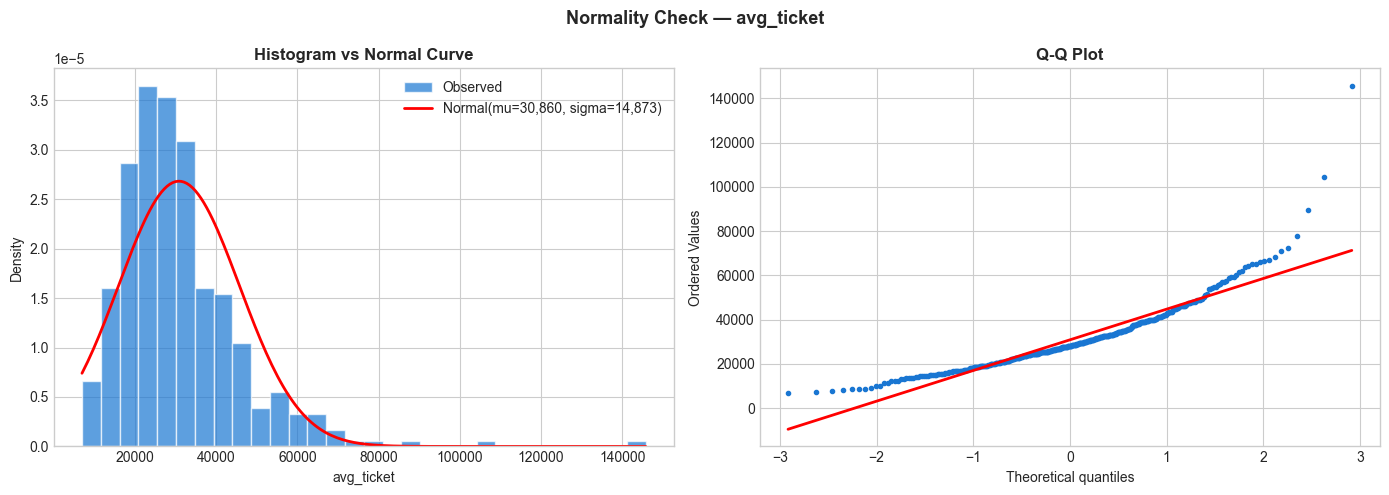

Figure saved: ..\reports\figures\03_normal_check_avg_ticket.png


In [4]:
# ===== Normal Distribution Visualization =====
def plot_normal_check(data: pd.Series, var_name: str) -> None:
    """Plots histogram with Normal curve overlay and Q-Q plot.

    Args:
        data: pd.Series — variable to check
        var_name: str — variable name for labels

    Returns:
        None
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(
        f'Normality Check — {var_name}',
        fontsize=13, fontweight='bold'
    )

    # Histogram + Normal curve
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    normal_curve = stats.norm.pdf(x, mu, sigma)

    axes[0].hist(data, bins=30, density=True,
                 color='#1976D2', alpha=0.7, edgecolor='white', label='Observed')
    axes[0].plot(x, normal_curve, 'r-', lw=2, label=f'Normal(mu={mu:,.0f}, sigma={sigma:,.0f})')
    axes[0].set_title('Histogram vs Normal Curve', fontweight='bold')
    axes[0].set_xlabel(var_name)
    axes[0].set_ylabel('Density')
    axes[0].legend()

    # Q-Q Plot
    stats.probplot(data, dist='norm', plot=axes[1])
    axes[1].set_title('Q-Q Plot', fontweight='bold')
    axes[1].get_lines()[0].set(color='#1976D2', markersize=3)
    axes[1].get_lines()[1].set(color='red', lw=2)

    plt.tight_layout()
    out = REPORTS_FIGURES / f'03_normal_check_{var_name.lower().replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


plot_normal_check(avg_ticket, 'avg_ticket')

---
## 4. Poisson Distribution — total_transactions

### 4.1 Why Poisson?

`total_transactions` counts discrete events (purchases) per customer over
a fixed time window — the classic Poisson scenario.

**Poisson conditions:**
- Events are independent ✅ (purchases are independent)
- Events occur at a constant average rate ✅ (lambda = mean transactions)
- Two events cannot occur simultaneously ✅ (each transaction is separate)

**Note:** This distribution is contextual — it does not directly feed a
hypothesis test in notebook 06, but it characterizes customer purchase
frequency, which informs the churn definition (H3).


In [5]:
# ===== Poisson Distribution Fit =====
lambda_hat = total_transactions.mean()
print('=' * 50)
print('POISSON FIT — total_transactions')
print('=' * 50)
print(f'Estimated lambda (mean): {lambda_hat:.4f}')
print(f'Variance               : {total_transactions.var():.4f}')
print(f'Variance / Mean ratio  : {total_transactions.var() / lambda_hat:.4f}')
print()
print('Note: For a perfect Poisson, Variance == Mean (ratio = 1.0)')
print('Ratio > 1 indicates overdispersion (more variance than Poisson predicts)')

POISSON FIT — total_transactions
Estimated lambda (mean): 3.0408
Variance               : 5.5789
Variance / Mean ratio  : 1.8347

Note: For a perfect Poisson, Variance == Mean (ratio = 1.0)
Ratio > 1 indicates overdispersion (more variance than Poisson predicts)


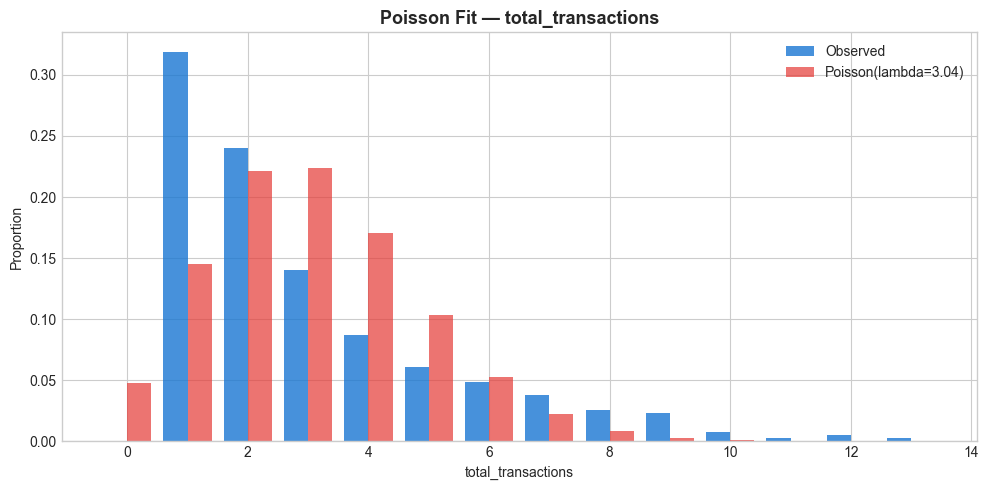

Figure saved: ..\reports\figures\03_poisson_fit_total_transactions.png


In [6]:
# ===== Poisson Visualization =====
def plot_poisson_fit(data: pd.Series, var_name: str) -> None:
    """Plots observed distribution vs theoretical Poisson PMF.

    Args:
        data: pd.Series — discrete count variable
        var_name: str — variable name for labels

    Returns:
        None
    """
    lambda_hat = data.mean()
    x = np.arange(0, data.max() + 1)
    poisson_pmf = stats.poisson.pmf(x, lambda_hat)

    # Align observed frequencies with x — fill missing values with 0
    observed = (
        data.value_counts(normalize=True)
        .reindex(x, fill_value=0)
        .values
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(x - 0.2, observed,
           width=0.4, color='#1976D2', alpha=0.8, label='Observed')
    ax.bar(x + 0.2, poisson_pmf,
           width=0.4, color='#E53935', alpha=0.7, label=f'Poisson(lambda={lambda_hat:.2f})')
    ax.set_title(f'Poisson Fit — {var_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel(var_name)
    ax.set_ylabel('Proportion')
    ax.legend()

    plt.tight_layout()
    out = REPORTS_FIGURES / f'03_poisson_fit_{var_name.lower().replace(" ", "_")}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


plot_poisson_fit(total_transactions, 'total_transactions')

---
## 5. Binomial Distribution — Churn

### 5.1 Why Binomial?

Churn is a **binary outcome**: a customer is either Dormant (churned=1)
or not (churned=0). With n independent customers and a constant probability
p of churning, the number of churned customers follows a Binomial distribution.

**Binomial conditions:**
- Fixed number of trials n ✅ (n=392 customers)
- Each trial has two outcomes ✅ (Dormant or not)
- Trials are independent ✅ (customer decisions are independent)
- Constant probability p ✅ (same churn probability across customers)

This directly justifies using a **proportion z-test** for H3.


In [7]:
# ===== Binomial Distribution — Churn =====
n_customers = len(churn_flag)
p_hat       = churn_flag.mean()         # observed churn rate
p_benchmark = 0.30                      # H3 benchmark
n_churned   = churn_flag.sum()

print('=' * 50)
print('BINOMIAL MODEL — Churn')
print('=' * 50)
print(f'n (customers)    : {n_customers}')
print(f'Observed churned : {n_churned} ({p_hat:.4f} = {p_hat*100:.1f}%)')
print(f'H3 benchmark     : p0 = {p_benchmark} ({p_benchmark*100:.0f}%)')
print()

# Expected churned under H0
expected_under_h0 = n_customers * p_benchmark
print(f'Expected churned under H0 (p=0.30): {expected_under_h0:.0f}')
print(f'Observed churned                  : {n_churned}')
print()

# Binomial probabilities
p_observed_or_more = 1 - stats.binom.cdf(n_churned - 1, n_customers, p_benchmark)
print(f'P(X >= {n_churned} | p=0.30) = {p_observed_or_more:.6f}')
print('(Preliminary signal for H3 — formal z-test in notebook 06)')

BINOMIAL MODEL — Churn
n (customers)    : 500
Observed churned : 207 (0.4140 = 41.4%)
H3 benchmark     : p0 = 0.3 (30%)

Expected churned under H0 (p=0.30): 150
Observed churned                  : 207

P(X >= 207 | p=0.30) = 0.000000
(Preliminary signal for H3 — formal z-test in notebook 06)


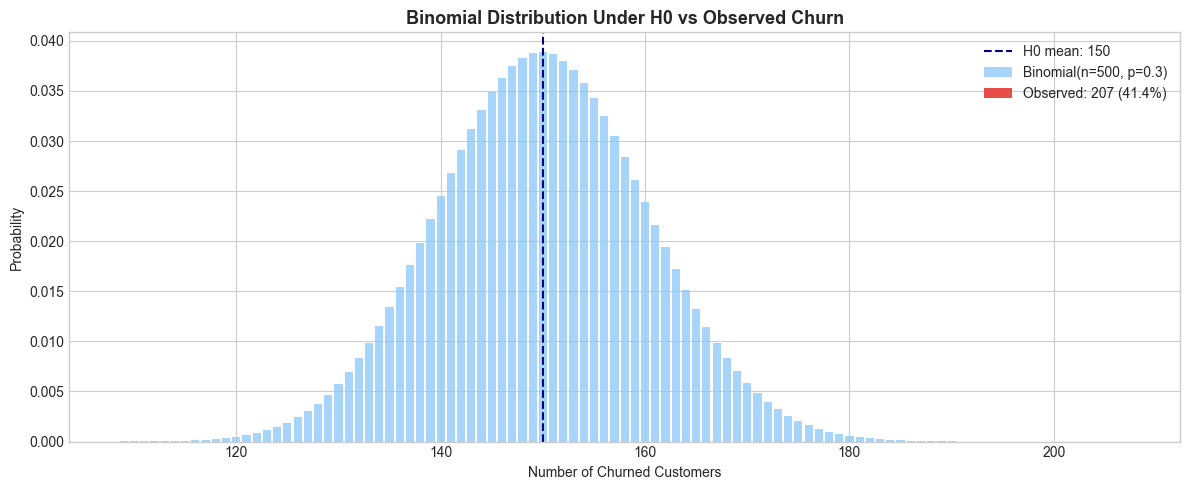

Figure saved: ..\reports\figures\03_binomial_churn.png


In [8]:
# ===== Binomial Visualization =====
def plot_binomial_churn(n: int, p_hat: float, p_benchmark: float, n_churned: int) -> None:
    """Plots Binomial PMF under H0 vs observed churn count.

    Highlights the observed value and the rejection region.

    Args:
        n: int — number of customers
        p_hat: float — observed churn proportion
        p_benchmark: float — H0 benchmark proportion
        n_churned: int — observed number of churned customers

    Returns:
        None
    """
    mu    = n * p_benchmark
    sigma = np.sqrt(n * p_benchmark * (1 - p_benchmark))
    x     = np.arange(max(0, int(mu - 4*sigma)), int(mu + 4*sigma) + 1)
    pmf   = stats.binom.pmf(x, n, p_benchmark)

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(x, pmf, color='#90CAF9', alpha=0.8, label=f'Binomial(n={n}, p={p_benchmark})')

    # Highlight observed value
    ax.bar([n_churned], stats.binom.pmf(n_churned, n, p_benchmark),
           color='#E53935', alpha=0.9, label=f'Observed: {n_churned} ({p_hat*100:.1f}%)')

    ax.axvline(x=mu, color='navy', linestyle='--', lw=1.5, label=f'H0 mean: {mu:.0f}')
    ax.set_title('Binomial Distribution Under H0 vs Observed Churn', fontsize=13, fontweight='bold')
    ax.set_xlabel('Number of Churned Customers')
    ax.set_ylabel('Probability')
    ax.legend()

    plt.tight_layout()
    out = REPORTS_FIGURES / '03_binomial_churn.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Figure saved: {out}')


plot_binomial_churn(n_customers, p_hat, p_benchmark, int(n_churned))

---
## 6. Distribution Summary — Test Justification

| Variable | Distribution | Evidence | Justifies | Hypothesis |
|----------|-------------|----------|-----------|------------|
| `avg_ticket` | Normal (or CLT) | Shapiro-Wilk p-value + Q-Q plot | One-sample t-test, Welch t-test, ANOVA | H1, H2, H4 |
| `total_transactions` | Poisson | Variance/Mean ratio | Contextual only | — |
| churn (Dormant) | Binomial(n=392, p=0.414) | Binary outcome + independence | Proportion z-test | H3 |

> **Key conclusion:** All distributional assumptions for the planned tests
> in notebook 06 are met. Even if `avg_ticket` departs from strict normality,
> CLT guarantees the sampling distribution of the mean is approximately
> Normal at n=392. Notebook 04 will verify this empirically.


In [9]:
# ===== Distribution Summary Table =====
summary = pd.DataFrame({
    'Variable'      : ['avg_ticket', 'total_transactions', 'churn_flag'],
    'Distribution'  : ['Normal / CLT', 'Poisson', 'Binomial'],
    'Key Parameter' : [
        f'mu={avg_ticket.mean():,.0f}, sigma={avg_ticket.std():,.0f}',
        f'lambda={total_transactions.mean():.2f}',
        f'n={n_customers}, p={p_hat:.4f}'
    ],
    'Test Enabled'  : ['t-test / ANOVA', 'Contextual', 'z-test proportion'],
    'Hypothesis'    : ['H1, H2, H4', '—', 'H3']
})

print('DISTRIBUTION SUMMARY')
display(summary)

DISTRIBUTION SUMMARY


,Variable,Distribution,Key Parameter,Test Enabled,Hypothesis
0,avg_ticket,Normal / CLT,"mu=30,860, sigma=14,873",t-test / ANOVA,"H1, H2, H4"
1,total_transactions,Poisson,lambda=3.04,Contextual,—
2,churn_flag,Binomial,"n=500, p=0.4140",z-test proportion,H3


---
## 7. LEAN Filter — Waste Elimination Review

| LEAN Question | Answer | Action |
|---------------|--------|--------|
| Did we fit only distributions connected to hypotheses? | ✅ Yes — Normal (H1/H2/H4), Binomial (H3), Poisson (context only) | No waste |
| Is Poisson justified even without a hypothesis? | ✅ Yes — characterizes purchase frequency, informs churn definition | Keep |
| Does Shapiro-Wilk rejection invalidate t-tests? | ✅ No — CLT applies at n=392, documented in notebook 04 | Proceed |
| Are all figures decision-relevant? | ✅ Yes — each plot validates a test assumption | Keep all |
| Did we over-engineer the distribution fitting? | ✅ No — 3 distributions, 3 variables, 3 hypotheses covered | MVA achieved |


---
## 8. Decisions Log — Lesson 3

| # | Decision | Rationale | Alternatives Considered | LEAN Value? |
|---|----------|-----------|------------------------|-------------|
| 1 | Use Shapiro-Wilk (not Anderson-Darling or KS test) | Standard for n < 5000; most widely recognized in academic work | KS test, Anderson-Darling | ✅ Standard choice |
| 2 | Include Poisson even without a direct hypothesis | Documents purchase frequency behavior; supports churn definition | Exclude entirely | ✅ Low cost, useful context |
| 3 | Use CLT argument as backup if Shapiro-Wilk rejects | n=392 >> 30; t-tests are robust to non-normality at this sample size | Non-parametric tests (Mann-Whitney) | ✅ Justified by theory |
| 4 | Model churn as Binomial (not Bernoulli) | We have n=392 trials — Binomial is the correct aggregate model | Bernoulli (individual level) | ✅ Correct level of analysis |


---
## 9. Next Steps — Lesson 4 Preview

In **Lesson 4 — Modeling (notebook 04)**, the following tasks will be completed:

1. Empirically verify the Central Limit Theorem on `avg_ticket`
2. Draw repeated samples of sizes n=10, 30, 50, 100, 200 and plot sampling distributions
3. Calculate Standard Error (SE = sigma/sqrt(n)) and verify convergence
4. Confirm that the sampling distribution of the mean approaches Normal as n increases
5. Connect CLT verification to the validity of t-tests planned in notebook 06

---

**Previous:** [02 - Data Understanding](./02_data_understanding.ipynb)  
**Next Phase -->** [04 - Modeling](./04_modeling.ipynb)
